In [1]:
import io
import string
import textwrap

import beaker
import cartopy.crs as ccrs
import faceted
import fsspec
import numpy as np
import pandas as pd
import wandb
import xarray as xr

import labels
import plotting
import utils

from matplotlib.patches import Patch
from upath import UPath

from labels import UNICODE_NAMES, UNITS_UNICODE

In [2]:
NOISE_FLOOR_ROOT = UPath("gs://vcm-ml-intermediate/2026-04-23-vertically-resolved-c96-1deg-shield-amip-ensemble-dataset-noise-floor")
with fsspec.open(str(NOISE_FLOOR_ROOT / "rmse_means.nc"), mode="rb") as f:  
    rmse_means = xr.open_dataset(f).sel(window_size=[5, 10])
with fsspec.open(str(NOISE_FLOOR_ROOT / "rmse_stdevs.nc"), mode="rb") as f:
    rmse_stdevs = xr.open_dataset(f).sel(window_size=[5, 10])

In [3]:
SECONDS_PER_DAY = 86400
PRECIPITATION = "PRATEsfc"
FROZEN_PRECIPITATION = "total_frozen_precipitation_rate"


def scale_precipitation(ds):
    if PRECIPITATION in ds:
        ds[PRECIPITATION] = SECONDS_PER_DAY * ds[PRECIPITATION]
        if FROZEN_PRECIPITATION in ds:
            ds[FROZEN_PRECIPITATION] = SECONDS_PER_DAY * ds[FROZEN_PRECIPITATION]
    return ds


def apply_curvefit_result(fit, x, function):
    result = xr.Dataset()
    for variable in fit.data_vars:
        if variable.endswith("_curvefit_coefficients"):
            c = fit[variable].sel(param="c")
            result[variable.replace("_curvefit_coefficients", "")] = function(x, c)
    return result


def extrapolate(ds, window_size=50):
    def function(x, c):
        return c / np.sqrt(x)

    fit = ds.curvefit("window_size", function)
    return apply_curvefit_result(fit, window_size, function)

In [4]:
rmse_extrapolated = extrapolate(rmse_means, 18)
stdev_extrapolated = extrapolate(rmse_stdevs, 18)

rmse_extrapolated = scale_precipitation(rmse_extrapolated)
stdev_extrapolated = scale_precipitation(stdev_extrapolated)

In [5]:
TEMPLATE = "2026-09-09-{model}-split-amip-ic{initial_condition}"
UNCOMBINED_CASES = {
    "ACE2-SHiELD": {
        1: utils.beaker_dataset_id_from_name(TEMPLATE.format(model="ACE2-SHiELD", initial_condition=1)),
        2: utils.beaker_dataset_id_from_name(TEMPLATE.format(model="ACE2-SHiELD", initial_condition=2)),
        3: utils.beaker_dataset_id_from_name(TEMPLATE.format(model="ACE2-SHiELD", initial_condition=3)),
        4: utils.beaker_dataset_id_from_name(TEMPLATE.format(model="ACE2-SHiELD", initial_condition=4)),
        5: utils.beaker_dataset_id_from_name(TEMPLATE.format(model="ACE2-SHiELD", initial_condition=5)),
    },
    "full energy-conserving rs0": {
        1: utils.beaker_dataset_id_from_name(TEMPLATE.format(model="full-energy-conserving-rs0", initial_condition=1)),
        2: utils.beaker_dataset_id_from_name(TEMPLATE.format(model="full-energy-conserving-rs0", initial_condition=2)),
        3: utils.beaker_dataset_id_from_name(TEMPLATE.format(model="full-energy-conserving-rs0", initial_condition=3)),
        4: utils.beaker_dataset_id_from_name(TEMPLATE.format(model="full-energy-conserving-rs0", initial_condition=4)),
        5: utils.beaker_dataset_id_from_name(TEMPLATE.format(model="full-energy-conserving-rs0", initial_condition=5)),
    },
    "full energy-conserving rs1": {
        1: utils.beaker_dataset_id_from_name(TEMPLATE.format(model="full-energy-conserving-rs1", initial_condition=1)),
        2: utils.beaker_dataset_id_from_name(TEMPLATE.format(model="full-energy-conserving-rs1", initial_condition=2)),
        3: utils.beaker_dataset_id_from_name(TEMPLATE.format(model="full-energy-conserving-rs1", initial_condition=3)),
        4: utils.beaker_dataset_id_from_name(TEMPLATE.format(model="full-energy-conserving-rs1", initial_condition=4)),
        5: utils.beaker_dataset_id_from_name(TEMPLATE.format(model="full-energy-conserving-rs1", initial_condition=5)),
    },
    "SHiELD": {
        1: utils.beaker_dataset_id_from_name("2026-03-24-amip-ic_0001-split-data-only-evaluator"),
        2: utils.beaker_dataset_id_from_name("2026-03-24-amip-ic_0002-split-data-only-evaluator")
    }
}

/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/beaker/util.py:25: RuntimeWarning: Found unknown field 'budget: 01HPM52AQCRXMD5BPZAMJG3TDZ' for data model 'Workspace'. This may be a newly added field that hasn't been defined in beaker-py yet. Please submit an issue report about this here:
https://github.com/allenai/beaker-py/issues/new?assignees=&labels=bug&template=bug_report.yml
  warnings.warn(
/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/beaker/util.py:25: RuntimeWarning: Found unknown field 'budget: 01KP6SETJ7CAHF1Y38AAZRZFY9' for data model 'Experiment'. This may be a newly added field that hasn't been defined in beaker-py yet. Please submit an issue report about this here:
https://github.com/allenai/beaker-py/issues/new?assignees=&labels=bug&template=bug_report.yml
  warnings.warn(
/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages

In [6]:
TEST_PREFIX = "test"
TRAIN_VALIDATE_PREFIX = "train-and-validate"


def open_beaker_dataset(dataset_id: str, path: str) -> xr.Dataset:
    """Given a beaker dataset ID and path within dataset, return an xarray
    dataset.

    Note: dataset must fit in memory. Requires h5netcdf backend.  Adapted from
    ace2-paper repo.
    """
    client = beaker.Beaker.from_env()
    file = client.dataset.get_file(dataset_id, path)
    ds = xr.open_dataset(io.BytesIO(file), engine="h5netcdf").load()
    if "source" in ds.dims:
        ds = ds.sel(source="target").drop_vars("source")
    return ds


def open_uncombined_dataset(dataset_ids: dict[int, str], path: str) -> xr.Dataset:
    """Given a dictionary of dataset IDs and a path, return an xarray dataset.
    """
    return xr.concat([open_beaker_dataset(dataset_id, path) for dataset_id in dataset_ids.values()], dim=pd.Index(dataset_ids.keys(), name="sample"))


def open_uncombined_datasets(cases: dict[str, dict[int, str]], path: str) -> xr.Dataset:
    datasets = {}
    for case, dataset_ids in cases.items():
        datasets[case] = open_uncombined_dataset(dataset_ids, path)
    return xr.concat(datasets.values(), dim="model").assign_coords(model=list(datasets.keys()))


def open_datasets(uncombined_cases: dict[str, dict[int, str]], path: str) -> xr.Dataset:
    train_and_validate_ds = open_uncombined_datasets(uncombined_cases, f"{TRAIN_VALIDATE_PREFIX}/{path}")
    test_ds = open_uncombined_datasets(uncombined_cases, f"{TEST_PREFIX}/{path}")
    return xr.concat([train_and_validate_ds, test_ds], dim="year")


def open_uncombined_dataset_first_sample(uncombined_cases: dict[str, dict[int, str]], path: str) -> xr.Dataset:
    datasets = {}
    for case, dataset_ids in uncombined_cases.items():
        datasets[case] = open_uncombined_dataset(dataset_ids, path).isel(sample=0)
    return xr.concat(datasets.values(), dim=pd.Index(uncombined_cases.keys(), name="model"))

In [7]:
mean_ds = open_uncombined_datasets(UNCOMBINED_CASES, f"{TEST_PREFIX}/time_mean_diagnostics.nc")

/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/beaker/util.py:25: RuntimeWarning: Found unknown field 'budget: 01KP6SETJ7CAHF1Y38AAZRZFY9' for data model 'Dataset'. This may be a newly added field that hasn't been defined in beaker-py yet. Please submit an issue report about this here:
https://github.com/allenai/beaker-py/issues/new?assignees=&labels=bug&template=bug_report.yml
  warnings.warn(


Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

/tmp/ipykernel_20048/2941695841.py:30: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'sample' ('sample',) The recommendation is to set join explicitly for this case.
  return xr.concat(datasets.values(), dim="model").assign_coords(model=list(datasets.keys()))


In [8]:
TITLE_TEMPLATE = """{name}
Global {metric_name} = {g:0.2f}
Land {metric_name} = {l:0.2f}
Ocean/sea-ice {metric_name} = {n:0.2f}"""

NO_NAME_TITLE_TEMPLATE = """Global {metric_name} = {g:0.2f}
Land {metric_name} = {l:0.2f}
Ocean/sea-ice {metric_name} = {n:0.2f}"""


def get_land_fraction(grid: str = "gaussian_grid_180_by_360") -> xr.DataArray:
    # Note the land fraction may not be identical on the coastlines for the C96
    # and C24 data regridded to a 4 degree Gaussian grid.  We have not paid
    # that close attention to non-global averages up to this point though, so
    # for now we will not worry about this detail.
    rename = {
        "grid_xt": "lon",
        "grid_yt": "lat",
        "grid_xt_bnds": "lon_bnds",
        "grid_yt_bnds": "lat_bnds",
    }
    ds = xr.open_zarr(
        f"gs://vcm-ml-raw-flexible-retention/2024-06-29-C96-SHiELD-AMIP/regridded-zarrs/{grid}/ic_0001/full_state.zarr"
    )
    ds = ds.rename(rename)
    return ds.isel(time=0).land_fraction.drop_vars("time")


def get_weights(grid: str = "gaussian_grid_180_by_360") -> xr.Dataset:
    land_fraction = get_land_fraction(grid)
    non_land_fraction = 1 - land_fraction
    area_weights = np.cos(np.deg2rad(land_fraction.lat)).broadcast_like(land_fraction)
    return (
        xr.concat(
            [
                area_weights,
                area_weights * land_fraction,
                area_weights * non_land_fraction,
            ],
            dim=pd.Index(["global", "land", "non-land"], name="region"),
        )
        .drop_vars(["lon", "lat"])
        .load()
    )


def get_title(metric, variable, model, metric_name):
    sel_kwargs = {"model": model}
    g = metric.sel(region="global", **sel_kwargs)[variable].item()
    l = metric.sel(region="land", **sel_kwargs)[variable].item()
    n = metric.sel(region="non-land", **sel_kwargs)[variable].item()
    return NO_NAME_TITLE_TEMPLATE.format(metric_name=metric_name, g=g, l=l, n=n)

In [9]:
mean_ds = mean_ds.rename({v: v.replace("gen_map-", "") for v in mean_ds.data_vars}).drop_vars([v for v in mean_ds.data_vars if "bias" in v])

In [10]:
mean_ds = scale_precipitation(mean_ds)

In [11]:
ensemble_mean_ds = mean_ds.sel(sample=slice(None, 2)).mean("sample")

In [12]:
ensemble_mean_bias_ds = ensemble_mean_ds.drop_sel(model="SHiELD") - ensemble_mean_ds.sel(model="SHiELD")

In [13]:
weights = get_weights("gaussian_grid_180_by_360")
regional_mean_bias = ensemble_mean_bias_ds.weighted(weights).mean(["lat", "lon"]).compute()
rmse = np.sqrt((ensemble_mean_bias_ds ** 2).weighted(weights).mean(["lat", "lon"])).compute()
rmse = rmse[labels.UNITS.keys()].drop_vars(["HGTsfc", "DSWRFtoa"])

Exception in callback PollerCompletionQueue._handle_events()()
handle: <Handle PollerCompletionQueue._handle_events()()>
Traceback (most recent call last):
  File "/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/asyncio/events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "src/python/grpcio/grpc/_cython/_cygrpc/aio/completion_queue.pyx.pxi", line 154, in grpc._cython.cygrpc.PollerCompletionQueue._handle_events
BlockingIOError: [Errno 11] Resource temporarily unavailable


In [14]:
combined_rmse = xr.concat([rmse.sel(region="global"), rmse_extrapolated.assign_coords(model="noise-floor")[list(rmse.data_vars)]], dim="model")

In [15]:
normalized_error = combined_rmse.drop_sel(model="noise-floor") / combined_rmse.sel(model="noise-floor")
normalized_error.to_array("variable").mean("variable")

<xarray.DataArray (model: 3)> Size: 24B
array([2.04430193, 2.32565764, 2.63124053])
Coordinates:
  * model    (model) <U26 312B 'ACE2-SHiELD' ... 'full energy-conserving rs1'
    region   StringDType(na_object=nan) 16B 'global'
    param    <U1 4B 'c'

In [16]:
error_bars = 2 * stdev_extrapolated  # 95% confidence interval
error_bars = error_bars[list(combined_rmse.data_vars)]
error_bars = error_bars.to_array().sortby("variable").to_dataframe(name="error")

In [17]:
error_bars_ds = (2 * stdev_extrapolated[list(combined_rmse.data_vars)])
unambiguously_worse = (combined_rmse.sel(model="ACE2-SHiELD") + error_bars_ds) < (combined_rmse.sel(model="full energy-conserving rs0") - error_bars_ds)
for v, da in unambiguously_worse.items():
    if da.item():
        print(v)

surface_temperature
air_temperature_2
air_temperature_1
specific_total_water_1
specific_total_water_0
USWRFsfc
ULWRFsfc
TMP2m


In [18]:
error_bars_ds = (2 * stdev_extrapolated[list(combined_rmse.data_vars)])
unambiguously_worse = (combined_rmse.sel(model="ACE2-SHiELD") + error_bars_ds) < (combined_rmse.sel(model="full energy-conserving rs1") - error_bars_ds)
for v, da in unambiguously_worse.items():
    if da.item():
        print(v)

surface_temperature
air_temperature_5
air_temperature_4
air_temperature_3
air_temperature_2
air_temperature_1
air_temperature_0
specific_total_water_7
specific_total_water_6
specific_total_water_3
specific_total_water_2
specific_total_water_1
specific_total_water_0
PRATEsfc
tendency_of_total_water_path_due_to_advection
DLWRFsfc
USWRFsfc
ULWRFsfc
TMP2m


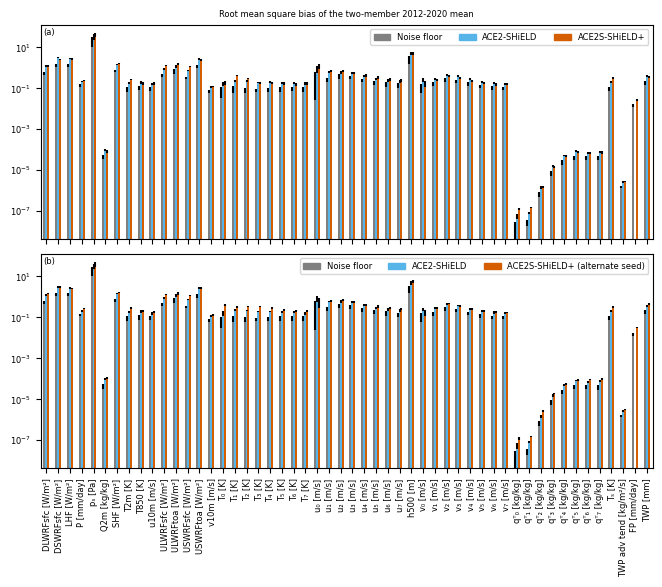

In [19]:
plotting.configure_style(fontsize=6)

import matplotlib.patches as mpatches
BASELINE = "ACE2-SHiELD"
MAIN_MODEL = "full energy-conserving rs0"
ALTERNATE_MODEL = "full energy-conserving rs1"


COLORS = {
    "noise-floor": "gray",
    BASELINE: "C0",
    MAIN_MODEL: "C4",
    ALTERNATE_MODEL: "C4"
}

UNITS_UNICODE["PRATEsfc"] = "mm/day"
UNITS_UNICODE["total_frozen_precipitation_rate"] = "mm/day"

fig, axes = faceted.faceted(
    2,
    1,
    width=6.5,
    aspect=0.35,
    left_pad=0.33,
    bottom_pad=1.2,
    top_pad=0.2,
    right_pad=0.05,
    internal_pad=0.15,
)

for ax, model in zip(axes, (MAIN_MODEL, ALTERNATE_MODEL)):
    da = combined_rmse.sel(
        model=["noise-floor", BASELINE, model]
    ).to_array().sortby("variable")
    index = pd.Index(
        [f"{UNICODE_NAMES[name]} [{UNITS_UNICODE[name]}]" for name in da["variable"].to_numpy().tolist()],
    )
    da = da.assign_coords(variable=index)
    df = da.to_dataframe(name="RMSE").unstack(level=1)["RMSE"]

    err_df = pd.DataFrame(
        np.repeat(error_bars["error"].values[:, None], len(df.columns), axis=1),
        index=df.index,
        columns=df.columns,
    )
    err_df = err_df.where(df.notna())

    # Map the bar colors to the models using the COLORS dict, in model order
    model_order = ["noise-floor", BASELINE, model]
    bar_colors = [COLORS[mod] for mod in model_order]

    # When using df.plot.bar, 'color' expects either a single color or a list of colors
    # corresponding to the series (order matches the column order in df)
    df.plot.bar(
        ax=ax,
        logy=True,
        yerr=err_df,
        legend=False,
        color=bar_colors
    )
    ax.set_xlabel("")

    if model == ALTERNATE_MODEL:
        label = "ACE2S-SHiELD+ (alternate seed)"
    else:
        label = "ACE2S-SHiELD+"

    LEGEND_LABELS = {
        "noise-floor": "Noise floor",
        BASELINE: "ACE2-SHiELD",
        model: label,
    }

    # Add a legend with a patch for each color
    legend_handles = [
        mpatches.Patch(color=COLORS[model], label=LEGEND_LABELS[model])
        for model in model_order
    ]
    ax.legend(handles=legend_handles, loc="upper right", fontsize=6, ncol=3)
    ax.set_title("")
    ax.set_ylabel("")

for ax, label in zip(axes, string.ascii_lowercase):
    ax.annotate(
        f"({label})",
        xy=(0, 1),
        xytext=(2, -2),
        va="top",
        xycoords="axes fraction",
        textcoords="offset points",
    )

axes[0].set_title("Root mean square bias of the two-member 2012-2020 mean")
fig.patch.set_alpha(0.0)
fig.savefig("figure-S02.png", dpi=300)
fig.savefig("figure-S02.pdf")
